# Семинар: токенайзеры, размеры тензоров и attention

В этом ноутбуке три части:

1. **Токенайзеры**: сравниваем разные токенайзеры из `transformers` на английском, русском, китайском и коде.
2. **Перемножение тензоров**: учимся следить за размерами в линейных слоях и батчах.
3. **Attention**: смотрим параметры модели, предсказываем размеры тензоров и визуализируем attention.


## 0. Установка и импорты

In [1]:
# Если чего-то не хватает, раскомментируйте:
# !pip install -q transformers sentencepiece matplotlib torch

import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModel,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


d:\Shared\Documents\Уник\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Токенайзеры

Будем смотреть, как разные токенайзеры режут:
- английский,
- русский,
- китайский,
- код.

Важно: один и тот же текст может разбиваться очень по-разному. Это зависит от:
- алгоритма токенизации,
- словаря,
- языков, на которых обучали токенайзер,
- того, использует ли он byte-level BPE, SentencePiece и т.д.


In [2]:
texts = {
    'english': 'The small dog sleeps on the carpet.',
    'russian': 'Маленькая собака спит на коврике.',
    'chinese': '小狗睡在地毯上。',
    'code': 'def attention(q, k, v):\n    return softmax(q @ k.T) @ v',
}

tokenizer_names = {
    'bert-base-uncased': 'BERT WordPiece',
    'gpt2': 'GPT-2 byte-level BPE',
    'google/mt5-small': 'mT5 SentencePiece',
    'xlm-roberta-base': 'XLM-R SentencePiece',
}

def inspect_tokenizer(tok_name, text):
    tok = AutoTokenizer.from_pretrained(tok_name)
    encoded = tok(text, return_tensors='pt')
    tokens = tok.convert_ids_to_tokens(encoded['input_ids'][0])
    print(f'=== {tok_name} ===')
    print('Text:   ', repr(text))
    print('Tokens: ', tokens)
    print('N toks: ', len(tokens))
    print("vocab_size:", tok.vocab_size)
    print("full_vocab_size:", len(tok.get_vocab()))
    print()

for tok_name in tokenizer_names:
    for lang, text in texts.items():
        inspect_tokenizer(tok_name, text)


=== bert-base-uncased ===
Text:    'The small dog sleeps on the carpet.'
Tokens:  ['[CLS]', 'the', 'small', 'dog', 'sleeps', 'on', 'the', 'carpet', '.', '[SEP]']
N toks:  10
vocab_size: 30522
full_vocab_size: 30522

=== bert-base-uncased ===
Text:    'Маленькая собака спит на коврике.'
Tokens:  ['[CLS]', 'м', '##а', '##л', '##е', '##н', '##ь', '##ка', '##я', 'с', '##о', '##б', '##а', '##ка', 'с', '##п', '##и', '##т', 'н', '##а', 'к', '##ов', '##р', '##и', '##к', '##е', '.', '[SEP]']
N toks:  28
vocab_size: 30522
full_vocab_size: 30522

=== bert-base-uncased ===
Text:    '小狗睡在地毯上。'
Tokens:  ['[CLS]', '小', '[UNK]', '[UNK]', '[UNK]', '地', '[UNK]', '上', '。', '[SEP]']
N toks:  10
vocab_size: 30522
full_vocab_size: 30522

=== bert-base-uncased ===
Text:    'def attention(q, k, v):\n    return softmax(q @ k.T) @ v'
Tokens:  ['[CLS]', 'def', 'attention', '(', 'q', ',', 'k', ',', 'v', ')', ':', 'return', 'soft', '##max', '(', 'q', '@', 'k', '.', 't', ')', '@', 'v', '[SEP]']
N toks:  24
vocab_si

KeyboardInterrupt: 

# Домашние мини-упражнения

1. Взять еще один токенайзер и сравнить его на русском и на коде.
2. Для заданных `B, T, d_model, h` вручную выписать размеры `Q, K, V` и `QK^T`.
3. Для еще одной модели из `transformers` найти число слоев, голов и размерность. Есть ли в ее механизме внимания интересные особенности?
4. Найти конкретный параметр, который соответствует `W_K`.
5. Подобрать голову attention с наиболее интересным паттерном и описать его словами.


## УПРАЖНЕНИЕ 1

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased")
model = AutoModelForMaskedLM.from_pretrained("google-bert/bert-base-multilingual-cased")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4206.63it/s]
BertForMaskedLM LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def inspect_tokenizer(tok_name, text):
    tok = AutoTokenizer.from_pretrained(tok_name)
    encoded = tok(text, return_tensors='pt')
    tokens = tok.convert_ids_to_tokens(encoded['input_ids'][0])
    print(f'=== {tok_name} ===')
    print('Text:   ', repr(text))
    print('Tokens: ', tokens)
    print('N toks: ', len(tokens))
    print("vocab_size:", tok.vocab_size)
    print("full_vocab_size:", len(tok.get_vocab()))
    print()

In [ ]:
texts = {
    'english': 'The small dog sleeps on the carpet.',
    'russian': 'Маленькая собака спит на коврике.',
    'chinese': '小狗睡在地毯上。',
    'code': 'def attention(q, k, v):\n    return softmax(q @ k.T) @ v',
}

tokenizer = 'bert-base-multilingual-cased'
tokenizer_description = 'BERT Multilingual'


for lang, text in texts.items():
    inspect_tokenizer(tokenizer, text)

=== bert-base-multilingual-cased ===
Text:    'The small dog sleeps on the carpet.'
Tokens:  ['[CLS]', 'The', 'small', 'dog', 'sleep', '##s', 'on', 'the', 'car', '##pet', '.', '[SEP]']
N toks:  12
vocab_size: 119547
full_vocab_size: 119547

=== bert-base-multilingual-cased ===
Text:    'Маленькая собака спит на коврике.'
Tokens:  ['[CLS]', 'М', '##ален', '##ька', '##я', 'со', '##бак', '##а', 'с', '##пит', 'на', 'ко', '##вр', '##ике', '.', '[SEP]']
N toks:  16
vocab_size: 119547
full_vocab_size: 119547

=== bert-base-multilingual-cased ===
Text:    '小狗睡在地毯上。'
Tokens:  ['[CLS]', '小', '狗', '睡', '在', '地', '毯', '上', '。', '[SEP]']
N toks:  10
vocab_size: 119547
full_vocab_size: 119547

=== bert-base-multilingual-cased ===
Text:    'def attention(q, k, v):\n    return softmax(q @ k.T) @ v'
Tokens:  ['[CLS]', 'def', 'attention', '(', 'q', ',', 'k', ',', 'v', ')', ':', 'return', 'soft', '##max', '(', 'q', '@', 'k', '.', 'T', ')', '@', 'v', '[SEP]']
N toks:  24
vocab_size: 119547
full_vocab_size

In [ ]:
rows = []

tok = AutoTokenizer.from_pretrained(tokenizer)
row = {'tokenizer': tokenizer_description}
for lang, text in texts.items():
    n = len(tok(text)['input_ids'])
    row[lang] = n
rows.append(row)

for row in rows:
    print(row)

{'tokenizer': 'BERT Multilingual', 'english': 12, 'russian': 16, 'chinese': 10, 'code': 24}


### ВЫВОД ПО УПРАЖНЕНИЮ 1

Получен следующий результат - для русского языка количество токенов равно 16, что меньше чем у GPT-2, но больше, чем у XLM-R и mT5, это обусловлено тем, что у них есть разница в алгоритме токенизации. 

* BERT Multilingual — WordPiece
* XLM-R — SentencePiece
* mT5 — SentencePiece

WordPiece и SentencePiece по-разному строят словарь. При этом у XLM-R словарь 250 000 токенов, у mT5 — 250 000, а у multilingual BERT — всего 119 000.

## УПРАЖНЕНИЕ 2

In [ ]:
B = 3
T = 10
d_model = 512
h = 8
d_k = d_model // h

print('X      :', (B, T, d_model))
print('Q, K, V:', (B, h, T, d_k))
print('Scores :', (B, h, T, T))
print('d_k:', d_k)


X      : (3, 10, 512)
Q, K, V: (3, 8, 10, 64)
Scores : (3, 8, 10, 10)
d_k: 64


## УПРАЖНЕНИЕ 3

In [ ]:
cfg = AutoConfig.from_pretrained("microsoft/phi-2")
print(cfg)

PhiConfig {
  "architectures": [
    "PhiForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 50256,
  "dtype": "float16",
  "embd_pdrop": 0.0,
  "eos_token_id": 50256,
  "hidden_act": "gelu_new",
  "hidden_size": 2560,
  "initializer_range": 0.02,
  "intermediate_size": 10240,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 2048,
  "model_type": "phi",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 32,
  "pad_token_id": null,
  "partial_rotary_factor": 0.4,
  "qk_layernorm": false,
  "resid_pdrop": 0.1,
  "rope_parameters": {
    "partial_rotary_factor": 0.4,
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": false,
  "transformers_version": "5.5.0",
  "use_cache": true,
  "vocab_size": 51200
}



In [ ]:
hidden_size = getattr(cfg, 'hidden_size')
num_attention_heads = getattr(cfg, 'num_attention_heads')
num_hidden_layers = getattr(cfg, 'num_hidden_layers')
d_k = hidden_size / num_hidden_layers 

print(f'{tokenizer:30s} hidden_size={hidden_size}, num_attention_heads={num_attention_heads}, num_hidden_layers={num_hidden_layers}, d_k={d_k}')

bert-base-multilingual-cased   hidden_size=2560, num_attention_heads=32, num_hidden_layers=32, d_k=80.0


### Особенность данной модели

RoPE (Rotary Position Embedding) — это метод из paper "RoFormer" (Su et al., 2021).

Модель должна понимать порядок токенов. Например "собака кусает человека" и "человек кусает собаку" — разный смысл. BERT решал это через абсолютные positional embeddings — просто прибавлял вектор позиции к embedding токена.

Идея RoPE:
Вместо того чтобы добавлять позицию к токену, RoPE вращает векторы Q и K на угол, зависящий от позиции. Формально для позиции mm
m:
Qm​=Rm​⋅Q,Kn​=Rn​⋅K

где RmR_m
Rm​ — матрица вращения. Тогда скалярное произведение Qm⋅KnQ_m \cdot K_n
Qm​⋅Kn​ автоматически зависит только от
относительного расстояния m−nm - n
m−n между токенами, а не от абсолютных позиций.


## УПРАЖНЕНИЕ 4

In [ ]:
for name, param in model.named_parameters():
    lname = name.lower()
    if ('key' in lname) or ('k_proj' in lname) or ('c_attn' in lname):
        print(name, tuple(param.shape))

bert.encoder.layer.0.attention.self.key.weight (768, 768)
bert.encoder.layer.0.attention.self.key.bias (768,)
bert.encoder.layer.1.attention.self.key.weight (768, 768)
bert.encoder.layer.1.attention.self.key.bias (768,)
bert.encoder.layer.2.attention.self.key.weight (768, 768)
bert.encoder.layer.2.attention.self.key.bias (768,)
bert.encoder.layer.3.attention.self.key.weight (768, 768)
bert.encoder.layer.3.attention.self.key.bias (768,)
bert.encoder.layer.4.attention.self.key.weight (768, 768)
bert.encoder.layer.4.attention.self.key.bias (768,)
bert.encoder.layer.5.attention.self.key.weight (768, 768)
bert.encoder.layer.5.attention.self.key.bias (768,)
bert.encoder.layer.6.attention.self.key.weight (768, 768)
bert.encoder.layer.6.attention.self.key.bias (768,)
bert.encoder.layer.7.attention.self.key.weight (768, 768)
bert.encoder.layer.7.attention.self.key.bias (768,)
bert.encoder.layer.8.attention.self.key.weight (768, 768)
bert.encoder.layer.8.attention.self.key.bias (768,)
bert.encod

W_k первого слоя - bert.encoder.layer.0.attention.self.key.weight (768, 768)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4551.25it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<class 'tuple'> 12
torch.Size([1, 12, 18, 18])


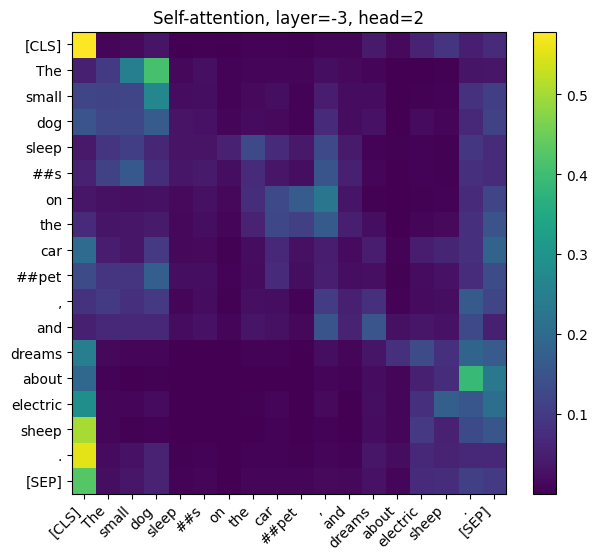

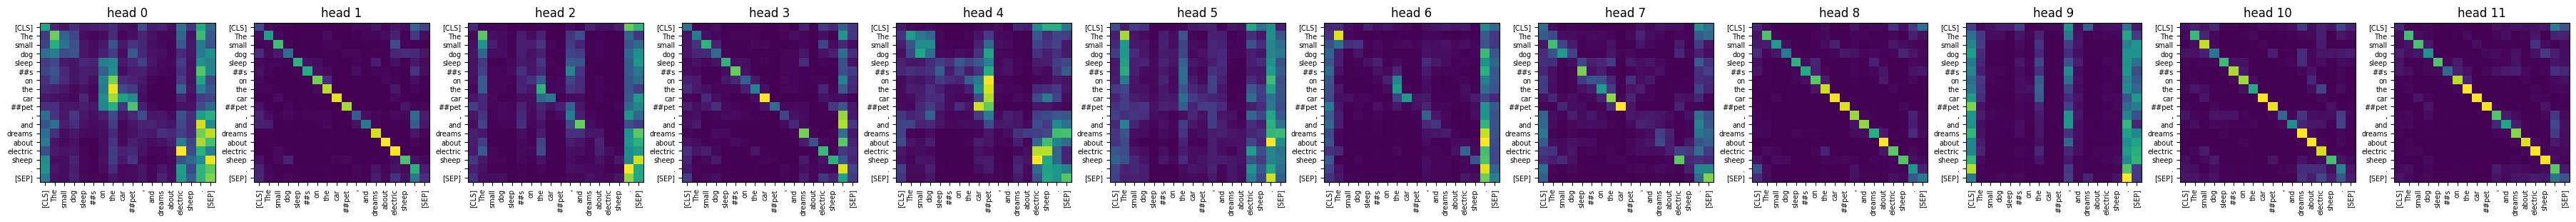

In [ ]:
model_name = tokenizer
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, attn_implementation='eager')
model.eval()

text = 'The small dog sleeps on the carpet, and dreams about electric sheep.'
batch = tok(text, return_tensors='pt')

with torch.no_grad():
    out = model(**batch, output_attentions=True, return_dict=True)

print(type(out.attentions), len(out.attentions))
print(out.attentions[0].shape)  # (batch, heads, seq, seq)


layer = -3
head = 2

attn = out.attentions[layer][0, head].cpu().numpy()
tokens = tok.convert_ids_to_tokens(batch['input_ids'][0])

plt.figure(figsize=(7, 6))
plt.imshow(attn, aspect='auto')
plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
plt.yticks(range(len(tokens)), tokens)
plt.title(f'Self-attention, layer={layer}, head={head}')
plt.colorbar()
plt.show()


# Перебор нескольких голов последнего слоя
layer = -1
num_heads = out.attentions[layer].shape[1]

fig, axes = plt.subplots(1, num_heads, figsize=(3 * num_heads, 3), constrained_layout=True)

for h in range(num_heads):
    ax = axes[h]
    mat = out.attentions[layer][0, h].cpu().numpy()
    ax.imshow(mat, aspect='auto')
    ax.set_title(f'head {h}')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=7)

plt.show()


В многих головах, например в head 1, head 3, head 8, head 10, head 11 явно видно "локальный паттерн" - каждый токен смотрит в основном на себя и ближайших соседей. на Head 6 все токены смотрят на 1 конкретный токен - на точку ".", такой же паттерн был у DistilBERT - голова специализируется на пунктуации как синтаксическом маркере границы предложения.